# Trabajo Práctico Aprendizaje Automático 1

In [1]:
import pandas as pd
import numpy as np


Fijamos una semilla para tener reproducibilidad en los resultados

In [2]:
SEED = 42
rng = np.random.default_rng(SEED)

## 1. Separación de datos

Primero que nada guardamos los datos que vamos a usar en el trabajo.

In [3]:
data = pd.read_csv('../Data/data.csv')

Luego lo que debemos hacer antes de empezar con el análisis exploratorio y el desarrollo de modelos es, dividir nuestros datos en desarrollo y control. Esto se hace con el objetivo de que al final del trabajo podamos reportar la performance esperada del modelo final con datos de la vida real.

Para hacer esto pensamos dos enfoques:

1. Mezclar todos los datos y quedarnos con el porcentaje deseado.

2. Mezclar todos los datos y quedarnos con el porcentaje deseado pero estratificando. 

Finalmente mostramos el código de ambas pero nos quedaremos con la segunda opción. Dado que los datos disponibles representan a la "realidad", resulta interesante mantener la distribución de clases en el grupo de desarrollo y control.

In [4]:
#Defino el porcentaje que vamos a usar para control. Arbitrario.. nos pareció mucho usar el 20%. 

porcent = 0.10

### Opción 1:

In [5]:
# Mezclamos los datos directamente del dataframe. 
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)

#Tomamos el porcentaje de control y desarrollo
n_control = int(len(data)*porcent)

#Dividimos..
data_control = data.iloc[:n_control].reset_index(drop=True)
data_dev = data.iloc[n_control:].reset_index(drop=True)

### Opción 2:

In [6]:
#Primero obtenemos los índices de cada clase en el data frame, ya que queremos estratificar. Tuve que agregar los .copy() porque me tiraba error.
indices_pos = data[data['target'] == 1].index.to_numpy().copy()
indices_neg = data[data['target'] == 0].index.to_numpy().copy()

# Luego mezclamos los índices de cada clase. 
rng.shuffle(indices_pos)
rng.shuffle(indices_neg)

# Calculamos la cantidad de instancias de control. ACA es la parte donde se estratifica.
n_control_pos = int(np.round(len(indices_pos) * porcent))
n_control_neg = int(np.round(len(indices_neg) * porcent))

# Partimos los indices de cada clase en control y desarrollo.
idx_control_pos = indices_pos[:n_control_pos]
idx_dev_pos     = indices_pos[n_control_pos:]

idx_control_neg = indices_neg[:n_control_neg]
idx_dev_neg     = indices_neg[n_control_neg:]

#Concatenamos los indices de control y desarrollo de cada clase para obtener los índices finales.
idx_control = np.concatenate([idx_control_pos, idx_control_neg])
idx_dev     = np.concatenate([idx_dev_pos, idx_dev_neg])

# Y mezclamos para que no nos queden los positivos por un lado y los negativos por el otro. Esto nose si es al pedo
rng.shuffle(idx_control)
rng.shuffle(idx_dev)

# Finalmente construimos los dataframes de desarrollo y control 
data_dev = data.loc[idx_dev].reset_index(drop=True)
data_control = data.loc[idx_control].reset_index(drop=True)

# Verificación de la estratificación
print(f"Total de datos: {len(data)}")
print(f"Desarrollo: {len(data_dev)} filas | Proporción Positivos: {data_dev['target'].mean():.4f}")
print(f"Control:    {len(data_control)} filas  | Proporción Positivos: {data_control['target'].mean():.4f}")

Total de datos: 500
Desarrollo: 450 filas | Proporción Positivos: 0.2822
Control:    50 filas  | Proporción Positivos: 0.2800


## Análisis Exploratorio 

### Dimensión de los datos y datos faltantes.

In [7]:
# Ver la cantidad de filas y columnas en Desarrollo (debería ser 450, 201)
print("Dimensiones de Desarrollo:", data_dev.shape)

# Verificar si existe algún valor nulo/faltante en todo el DataFrame
total_nulos = data_dev.isnull().sum().sum()
print(f"Total de valores faltantes (NaN): {total_nulos}")

Dimensiones de Desarrollo: (450, 201)
Total de valores faltantes (NaN): 0


Las dimensiones son las esperadas y no hay datos faltantes!

### Distribución de la Variable Objetivo.

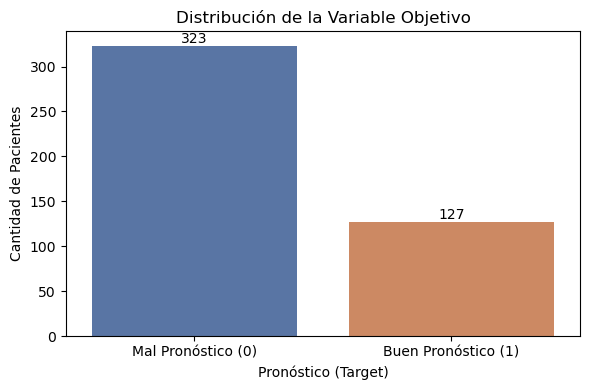

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data_dev, x='target', palette='deep',hue='target',legend =False)

plt.title("Distribución de la Variable Objetivo", fontsize=12)
plt.xlabel("Pronóstico (Target)")
plt.ylabel("Cantidad de Pacientes")
plt.xticks(ticks=[0, 1], labels=['Mal Pronóstico (0)', 'Buen Pronóstico (1)'])

# Mostrar valores numéricos arriba de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Se observa un claro desbalance de clases, dónde la clase mayoritaria es Mal Pronóstico (0). 

Notemos que para nuestros datos el error más costoso es el de Falsos Positivos. Ya que le diríamos a una persona que va a estar sana pero luego habría una recaída. En ese sentido, una de las métricas más importantes sería Precisión pero cómo vimos en clase no basta evaluar a un modelo con solo Presicón o solo Recall. 

### Distribución de los Atributos

La idea es analizar brevemente la distribución de los atributos y sus magnitudes

In [9]:
#Separamos únicamente las 200 columnas de características (genes) en Desarrollo
X_dev = data_dev.drop(columns=['target'])

# Obtener los estadísticos descriptivos individuales por cada gen
stats_por_gen = X_dev.describe().T  # DataFrame de 200 filas (genes) x 8 columnas (mean, std, min, etc.)

# 3. Resumir la distribución global de esos estadísticos para el informe
resumen_escala = pd.DataFrame({
    'Métrica Génica': ['Media (mean)', 'Desvío Estándar (std)', 'Mínimo (min)', 'Mediana (50%)', 'Máximo (max)'],
    'Promedio Global': [
        stats_por_gen['mean'].mean(),
        stats_por_gen['std'].mean(),
        stats_por_gen['min'].mean(),
        stats_por_gen['50%'].mean(),
        stats_por_gen['max'].mean()
    ],
    'Mínimo Observado': [
        stats_por_gen['mean'].min(),
        stats_por_gen['std'].min(),
        stats_por_gen['min'].min(),
        stats_por_gen['50%'].min(),
        stats_por_gen['max'].min()
    ],
    'Máximo Observado': [
        stats_por_gen['mean'].max(),
        stats_por_gen['std'].max(),
        stats_por_gen['min'].max(),
        stats_por_gen['50%'].max(),
        stats_por_gen['max'].max()
    ]
})

print("=== RESUMEN GLOBAL DE LA ESCALA DE EXPRESIÓN DE ARN (200 GENES) ===")
print(resumen_escala.to_string(index=False))

=== RESUMEN GLOBAL DE LA ESCALA DE EXPRESIÓN DE ARN (200 GENES) ===
       Métrica Génica  Promedio Global  Mínimo Observado  Máximo Observado
         Media (mean)        -0.113287         -4.575857          4.495489
Desvío Estándar (std)         2.532922          0.910082         16.036777
         Mínimo (min)        -7.848469        -61.104819         -2.221443
        Mediana (50%)        -0.104087         -4.790362          4.796456
         Máximo (max)         7.449661          2.204044         53.185526


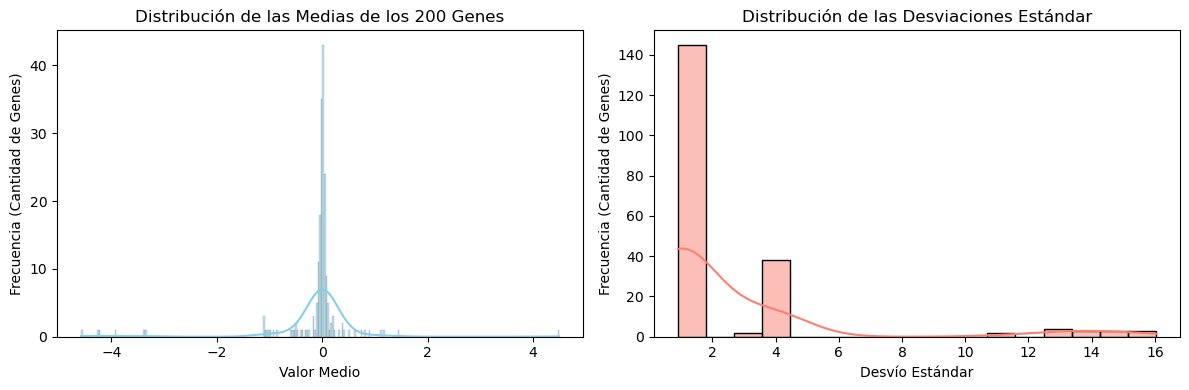

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma de las Medias de los 200 genes
sns.histplot(stats_por_gen['mean'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Distribución de las Medias de los 200 Genes")
axes[0].set_xlabel("Valor Medio")
axes[0].set_ylabel("Frecuencia (Cantidad de Genes)")

# Histograma de los Desvíos Estándar de los 200 genes
sns.histplot(stats_por_gen['std'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Distribución de las Desviaciones Estándar")
axes[1].set_xlabel("Desvío Estándar")
axes[1].set_ylabel("Frecuencia (Cantidad de Genes)")

plt.tight_layout()
plt.show()

+ Del análisis visual de las medias (histograma de $\mu$) se observa que la gran mayoría de los 200 genes presenta valores centrados alrededor de 0.

+ Si bien la mayor parte de los genes exhibe un desvío estándar acotado entre 1 y 2, se identifica un subconjunto de características que muestra una dispersión sensiblemente mayor, alcanzando valores cercanos a $\sigma \approx 4$. Esta presencia de genes con varianzas hasta 2 o 4 veces superiores a la media del grupo demuestra que las variables no se encuentran en una escala estrictamente idéntica.

Definimos una función para facilitar el gráfico de las curvas ROC:

In [11]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay  

def graficar_roc(modelo, nombre, n_puntos=8):

    #Primero, necesito los score continuos de cada modelo. Para eso, me fijo como los calcula

    #Si el modelo produce una probabilidad:
    if hasattr(modelo, "predict_proba"):
        y_score = cross_val_predict(
            modelo,
            X_train,
            y_train,
            cv=kf,
            method="predict_proba",
            n_jobs=-1
        )[:, 1]

    #Si el modelo no produce una probabilidad, pero si un score continuo (decision_function)
    else:
        y_score = cross_val_predict(
            modelo,
            X_train,
            y_train,
            cv=kf,
            method="decision_function",
            n_jobs=-1
        )

    # RocCurveDisplay reemplaza el plt.plot + fill_between + diagonal manual.
    # Calcula el AUCROC y dibuja la curva con las predicciones globales/oof (out of fold)
    display = RocCurveDisplay.from_predictions(
        y_train,
        y_score,
        name=nombre,
        plot_chance_level=True,
        chance_level_kw={"label": "Clasificador aleatorio"},
    )
    display.ax_.set_title(f"Curva ROC - {nombre}")
    display.ax_.grid(alpha=0.3)

    #Todo esto de aca abajo es para mostrar los tresholds en el grafico.

    #para cada trehsold evaluado, recupero un fpr y un tpr
    fpr, tpr, thresholds = roc_curve(y_train, y_score)

    #hay trehsolds infinitos en la evaluación de arriba. Los ignoro.
    idx_validos = np.where(np.isfinite(thresholds))[0]


    if len(idx_validos) > 0:

        #agarro n treshold distribuidos evenly
        idx_marcados = np.linspace(
            0,
            len(idx_validos) - 1,
            min(n_puntos, len(idx_validos)),
            dtype=int
        )

        #anoto cada punto elegido en el grafico
        for idx in idx_validos[idx_marcados]:
            display.ax_.scatter(fpr[idx], tpr[idx], s=22)
            display.ax_.annotate(
                f"{thresholds[idx]:.2f}",
                (fpr[idx], tpr[idx]),
                textcoords="offset points",
                xytext=(4, 4)
            )

    plt.show()

## 2. Construcción de modelos

### 2.1 Entrenar arbol de desición

Primero, armamos los train con la data ya separada por Desarrollo y Control:

In [12]:
X_train = data_dev.drop(columns=['target'])
y_train = data_dev['target']

Entrenamos un arbol de desición con altura maxima 3 e hiperparam por defecto

In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
#este modelo por ahora no se usa para nada, es la base
mode_full_train = DecisionTreeClassifier(max_depth=3)
mode_full_train.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

### 2.2: Evaluar K-Fold

Hago folds estratificados por desbalance

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score, average_precision_score, precision_recall_curve, auc
)



In [16]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=912)#comoteduelelaco...

kf por dentro tiene indexaciones por cada fold. Es decir, se ve algo asi:

fold 1: ((0,1,2,5),(3,4)) -> entreno con train[0] , train[1] ,..., y evaluo con 3,4. (escribir esto lindo)

In [17]:
#Calculo para no repetir abajo el auprc literal (area debajo de la curva roc) (porque sklearn calcula ap)
def auprc_theory(y_true, y_prob):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    return auc(recall, precision)


Se considero usar cross_validate de sklearn para obtener los scores por fold y recuperar los modelos e indices de validación (return_estimator=True, return_indices=True). Sin embargo, esto implicaba recuprar parametros integros del modelo que no tenemos muy claro utilizar, y era mas complejo que el bucle actual. 

Otra opción era combinar cross_validate con cross_val_predict, tambien de sklearn, para recuperar scores globales y por fold respectivamente, pero esto implicaba reentrenar el modelo por cada llamada. Nos resulto mas directo el siguiente approach

In [18]:


fold = 1 #no muy lindo, puede quedar mejor esto si se itera con un for pero queda bastante mas dificil de leer.
         #lo voy aumentando por cada for (es para printear info nomas)
         
#resultados fold quedan en este result_folds en orden, no es muy lindo. TODO: si se les ocurre como ponerlo mas lindo cambienlo
results_folds = []

y_pred_global_folds = np.empty(len(y_train)) #para score global
y_prob_global_folds = np.empty(len(y_train)) #para score global

for train_idx, val_idx in kf.split(X_train, y_train): #train idx: indices para entrenar fold i, val idx: indices para testear fold i


    X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx] #agarro features train y val para el fold i
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx] #agarro labels train y val para el fold i

    #lo sig como chequeo, not nescesario
    
    print(f"Cantidad de datos en el fold {fold} de train: {len(y_train_fold)}")
    print(f"Cantidad de datos en el fold {fold} de validation: {len(y_val_fold)}")
    print(f"Proporcion de datos positivos en el fold {fold} de train: {y_train_fold.mean():.4f}")
    print(f"Proporcion de datos positivos en el fold {fold} de validation: {y_val_fold.mean():.4f}")


    model = DecisionTreeClassifier(max_depth=3)
    model.fit(X_train_fold, y_train_fold) #entreno modelo en datos fold


    y_pred_train_fold = model.predict(X_train_fold) #predicciones del modelo entrenado en los datos de train fold
    y_pred_val_fold = model.predict(X_val_fold) #predicciones del modelo entrenado en los datos de validación fold
    
    y_prob_train_fold = model.predict_proba(X_train_fold)[:, 1] #probabilidades de la clase positiva para los datos de train fold
    y_prob_val_fold = model.predict_proba(X_val_fold)[:, 1] #probabilidades de la clase positiva para los datos de validación fold

    #Guardo las predicciones y probabilidades de las validaciones en su posc original, para luego calcular global
    y_pred_global_folds[val_idx] = y_pred_val_fold
    y_prob_global_folds[val_idx] = y_prob_val_fold

    ###Metricas de performance para cada fold
    results_folds.append({
        "Accuracy train": accuracy_score(y_train_fold, y_pred_train_fold),
        "Accuracy validation": accuracy_score(y_val_fold, y_pred_val_fold),
        "AUPRC train": auprc_theory(y_train_fold, y_prob_train_fold),
        "AUPRC validation": auprc_theory(y_val_fold, y_prob_val_fold),
        "AUCROC train": roc_auc_score(y_train_fold, y_prob_train_fold),
        "AUCROC validation": roc_auc_score(y_val_fold, y_prob_val_fold),
    })

    fold += 1



Cantidad de datos en el fold 1 de train: 360
Cantidad de datos en el fold 1 de validation: 90
Proporcion de datos positivos en el fold 1 de train: 0.2806
Proporcion de datos positivos en el fold 1 de validation: 0.2889
Cantidad de datos en el fold 2 de train: 360
Cantidad de datos en el fold 2 de validation: 90
Proporcion de datos positivos en el fold 2 de train: 0.2806
Proporcion de datos positivos en el fold 2 de validation: 0.2889
Cantidad de datos en el fold 3 de train: 360
Cantidad de datos en el fold 3 de validation: 90
Proporcion de datos positivos en el fold 3 de train: 0.2833
Proporcion de datos positivos en el fold 3 de validation: 0.2778
Cantidad de datos en el fold 4 de train: 360
Cantidad de datos en el fold 4 de validation: 90
Proporcion de datos positivos en el fold 4 de train: 0.2833
Proporcion de datos positivos en el fold 4 de validation: 0.2778
Cantidad de datos en el fold 5 de train: 360
Cantidad de datos en el fold 5 de validation: 90
Proporcion de datos positivos 

Los folds se encuentran bien distribuidos.

In [19]:
results_df = pd.DataFrame(results_folds)

#esto de aca abajo no lo tengo clarisimo tengo sueño mañana lo veo bien, es solo para ver resultados ahora
results_df.index = range(1, len(results_df) + 1)
results_df.index.name = "Fold"

display(results_df.round(3))

,Accuracy train,Accuracy validation,AUPRC train,AUPRC validation,AUCROC train,AUCROC validation
Fold,,,,,,
1,0.803,0.700,0.705,0.369,0.803,0.579
2,0.831,0.700,0.755,0.352,0.733,0.579
3,0.803,0.778,0.759,0.428,0.841,0.700
4,0.833,0.756,0.764,0.540,0.820,0.685
5,0.850,0.722,0.779,0.399,0.789,0.597


In [20]:
#agrego promedios
results_df.loc["Promedio"] = results_df.mean()
display(results_df.round(3))

,Accuracy train,Accuracy validation,AUPRC train,AUPRC validation,AUCROC train,AUCROC validation
Fold,,,,,,
1,0.803,0.700,0.705,0.369,0.803,0.579
2,0.831,0.700,0.755,0.352,0.733,0.579
3,0.803,0.778,0.759,0.428,0.841,0.700
4,0.833,0.756,0.764,0.540,0.820,0.685
5,0.850,0.722,0.779,0.399,0.789,0.597
Promedio,0.824,0.731,0.752,0.418,0.797,0.628


Calculos globales

In [21]:
accuracy_global = accuracy_score(y_train, y_pred_global_folds)
auprc_global = auprc_theory(y_train, y_prob_global_folds)
aucroc_global = roc_auc_score(y_train, y_prob_global_folds)

In [22]:
#Esto es medio feo, pero para meterlo a misma tabla
results_df.loc["Global"] = [
    np.nan,
    accuracy_global,
    np.nan,
    auprc_global,
    np.nan,
    aucroc_global
]

display(results_df.round(4))

,Accuracy train,Accuracy validation,AUPRC train,AUPRC validation,AUCROC train,AUCROC validation
Fold,,,,,,
1,0.8028,0.7000,0.7046,0.3694,0.8034,0.5793
2,0.8306,0.7000,0.7553,0.3525,0.7326,0.5787
3,0.8028,0.7778,0.7593,0.4275,0.8410,0.7003
4,0.8333,0.7556,0.7641,0.5399,0.8197,0.6849
5,0.8500,0.7222,0.7786,0.3986,0.7887,0.5966
Promedio,0.8239,0.7311,0.7524,0.4176,0.7971,0.6280
Global,NaN,0.7311,NaN,0.3896,NaN,0.6302


pd (postdata): esto nos deja un indexacion mixta para este df: numeros del 1 al 5 (folds) y string "Promedio" y "Global"!

Representación gráfica de AUPRC y AUCROC global en validation:

AttributeError: Line2D.set() got an unexpected keyword argument 'curve_kwargs'

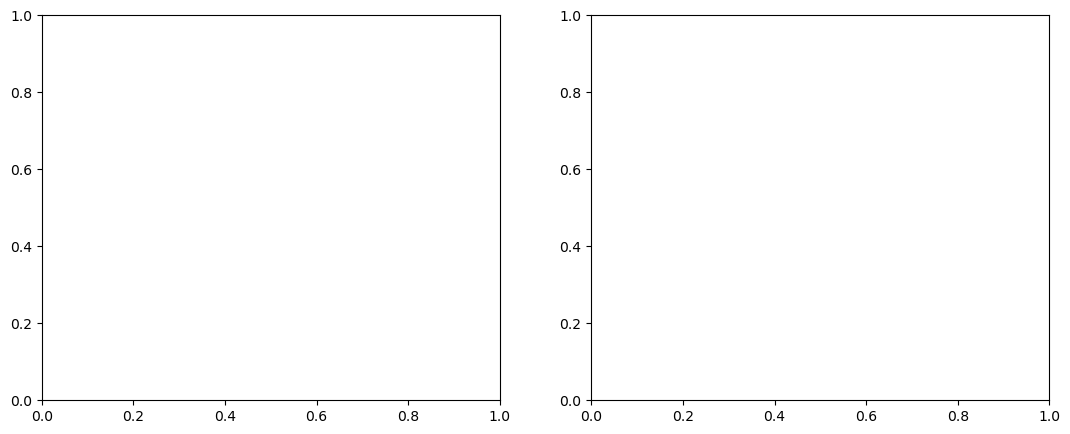

In [23]:
# Curvas ROC y Precision-Recall para el score GLOBAL

from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay


fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# ---------------- CURVA ROC ----------------

# RocCurveDisplay reemplaza el plt.plot + fill_between + diagonal manual.
# Calcula el AUCROC y dibuja la curva con las predicciones globales/oof (out of fold)
# valor de AUCROC mostrado (auc_global ya calculado más arriba con roc_auc_score).
RocCurveDisplay.from_predictions(
    y_train,
    y_prob_global_folds,
    ax=axes[0],
    plot_chance_level=True,
    curve_kwargs={"label": f"Curva ROC (área = {aucroc_global:.3f})"},
    chance_level_kw={"label": "Clasificador aleatorio"},
)

fpr_global, tpr_global, thresholds_roc = roc_curve(
    y_train,
    y_prob_global_folds
)

# Seleccionamos algunos thresholds para mostrar
idx_roc = np.linspace(
    1,
    len(thresholds_roc) - 1,
    8,
    dtype=int
)

for i in idx_roc:
    axes[0].scatter(
        fpr_global[i],
        tpr_global[i],
        s=25
    )

    axes[0].annotate(
        f"{thresholds_roc[i]:.2f}",
        (fpr_global[i], tpr_global[i]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

axes[0].set_title("Curva ROC global")
axes[0].grid(alpha=0.3)


# ---------------- CURVA PRECISION-RECALL ----------------

#PrecisionRecallDisplay reemplaza el plt.plot + fill_between manual.
# curve_kwargs para modificar el texto del plot (y linealizarl precisionrecall saltos)
PrecisionRecallDisplay.from_predictions(
    y_train,
    y_prob_global_folds,
    ax=axes[1],
    curve_kwargs={"label": f"Curva Precision-Recall (área = {auprc_global:.3f})",
                  "drawstyle": "default"},
)

precision_global_curve, recall_global_curve, thresholds_pr = precision_recall_curve(
    y_train,
    y_prob_global_folds
)

# Seleccionamos algunos thresholds para mostrar
idx_pr = np.linspace(
    0,
    len(thresholds_pr) - 1,
    8,
    dtype=int
)

for i in idx_pr:
    axes[1].scatter(
        recall_global_curve[i],
        precision_global_curve[i],
        s=25
    )

    axes[1].annotate(
        f"{thresholds_pr[i]:.2f}",
        (recall_global_curve[i], precision_global_curve[i]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=8
    )

axes[1].set_title("Curva Precision-Recall global")
axes[1].grid(alpha=0.3)


plt.tight_layout()
plt.show()

La curva ROC global alcanza un AUCROC de 0.642, lo que muestra una capacidad de discriminación moderada y superior al azar. La curva Precision-Recall presenta un AUPRC de 0.405 y refleja el compromiso entre recall y precision. Es decir, al intentar detectar más positivos, aumenta la cantidad de falsos positivos. La elección del umbral dependerá del costo relativo de cada tipo de error.

### 2.3 Evaluar configuraciones

In [24]:
from sklearn.model_selection import ParameterGrid

Primero hacemos un diccionario con los parámetros a utilizar y luego aplicamos ParameterGrid para crear la grilla.


In [25]:
parametros = {
    "max_depth": [3, 5, None],
    "criterion": ["gini", "entropy"]
}


In [ ]:
pg = list(ParameterGrid(parametros))


Ahora que podemos calcular scores globales con promedios, podemos utilizar cross_validate directamente

In [26]:
from sklearn.model_selection import cross_validate

resultados = []

for param in pg:

    model = DecisionTreeClassifier(**param)

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring="accuracy",
        return_train_score=True
    )

    resultados.append({
        "max_depth": param["max_depth"],
        "criterion": param["criterion"],
        "Accuracy train": scores["train_score"].mean(),
        "Accuracy validation": scores["test_score"].mean()
    })

NameError: name 'pg' is not defined

Finalmente, vemos los resultados:

In [27]:
resultados_df = pd.DataFrame(resultados)

resultados_df

""


## 3 Comparación de Algoritmos

### 3.1 Prueba de algoritmos

- Arboles de decisión:

In [28]:
from sklearn.model_selection import RandomizedSearchCV

# Espacio de búsqueda: 4 hiperparámetros (la consigna pide mínimo 4).
# Tres controlan el crecimiento/tamaño del árbol (capacidad) y uno el criterio de impureza.
espacio_arbol = {
    "max_depth": [3, 5, 10, 20, None],          # None = sin límite de profundidad (fila "Infinito" del 2.3)
    "criterion": ["gini", "entropy"],            # criterio de impureza para elegir cortes
    "max_leaf_nodes": [5, 10, 20, 50, 100, None],# techo a la cantidad de hojas (regiones); None = sin techo
    "min_samples_split": [2, 5, 10, 20, 50],     # mínimo de muestras en un nodo para permitir un corte
}                                                # valores acotados por el tamaño del dataset (~360 train/fold)

busqueda_arbol = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=SEED),  # random_state fija desempates internos del árbol
    param_distributions=espacio_arbol,
    n_iter=50,              # muestrea 50 de las 300 combinaciones posibles (5*2*6*5)
    scoring="roc_auc",      # métrica pedida por la consigna
    cv=kf,                  # el StratifiedKFold de la celda 23: mismos folds para todos los
                            # algoritmos y configs -> comparación justa entre modelos
    random_state=SEED,      # reproducibilidad del muestreo de combinaciones
    n_jobs=-1,              # paraleliza en todos los núcleos
)

busqueda_arbol.fit(X_train, y_train)   

print("Mejor configuración:", busqueda_arbol.best_params_)
print("Mejor AUCROC (CV):", busqueda_arbol.best_score_)   

# Tabla para el informe: top 10 configuraciones con media y desvío entre folds
resultados_arbol = pd.DataFrame(busqueda_arbol.cv_results_)
resultados_arbol = resultados_arbol.sort_values("rank_test_score")
resultados_arbol[["params", "mean_test_score", "std_test_score"]].head(10)

#Ojo; usa nombre test para cosas que nosotros llamamos val, pero cambiarlas a mano una tabla ya dada no vale la pena
#Lo mismo sucede en KNN, y SVM.

Mejor configuración: {'min_samples_split': 10, 'max_leaf_nodes': 50, 'max_depth': 3, 'criterion': 'gini'}
Mejor AUCROC (CV): 0.6393048076923077


,params,mean_test_score,std_test_score
30,"{'min_samples_split': 10, 'max_leaf_nodes': 50...",0.639305,0.057130
36,"{'min_samples_split': 10, 'max_leaf_nodes': 10...",0.639305,0.057130
8,"{'min_samples_split': 2, 'max_leaf_nodes': 10,...",0.636901,0.058795
20,"{'min_samples_split': 20, 'max_leaf_nodes': 50...",0.630270,0.060465
21,"{'min_samples_split': 20, 'max_leaf_nodes': 10...",0.627658,0.053334
39,"{'min_samples_split': 20, 'max_leaf_nodes': 20...",0.625977,0.049184
18,"{'min_samples_split': 20, 'max_leaf_nodes': No...",0.600543,0.039101
11,"{'min_samples_split': 10, 'max_leaf_nodes': No...",0.600175,0.096139
3,"{'min_samples_split': 50, 'max_leaf_nodes': 10...",0.597188,0.033001
33,"{'min_samples_split': 50, 'max_leaf_nodes': 10...",0.597188,0.033001


Representación gráfica del mejor valor de AUCROC:

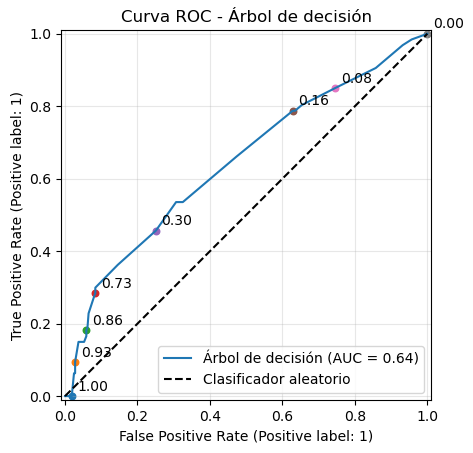

In [29]:
graficar_roc(
    busqueda_arbol.best_estimator_,
    "Árbol de decisión"
)

La curva ROC del árbol de decisión alcanza un AUCROC de 0.644, lo que indica una capacidad de discriminación moderada y superior a la de un clasificador aleatorio. Al disminuir el umbral, aumenta la tasa de verdaderos positivos, aunque también se incrementa la proporción de falsos positivos.

- KNN:

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline: estandarización + KNN como un solo estimador.
# KNN usa distancias, y sin escalar las features de mayor rango dominan el cálculo.
# Al ir dentro del pipeline, el scaler se ajusta SOLO con el train de cada fold
# (media y desvío del train, aplicados a validación) -> sin data leakage.
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

# Prefijo "knn__" = "este parámetro es del paso llamado knn del pipeline"
espacio_vecinos = {
    "knn__n_neighbors": [3, 10, 50, 150, 250],   # de k chico (flexible, riesgo de overfit) a k grande (suave, riesgo de underfit). tope < ~360 muestras de train por fold
    "knn__weights": ["uniform", "distance"],     # voto parejo vs. ponderado por cercanía
    "knn__p": [1, 2],                            # métrica Minkowski: 1=Manhattan, 2=euclídea; en alta dimensión (200 features) la métrica puede afectar cuán informativas son las distancias
}

busqueda_vecinos = RandomizedSearchCV(
    estimator=pipe_knn,          # el pipeline entero, no el KNN suelto
    param_distributions=espacio_vecinos,
    n_iter=20,                   # el espacio tiene exactamente 5*2*2 = 20 combinaciones: con n_iter=20 la búsqueda es en la práctica exhaustiva (declararlo en el informe)
    scoring="roc_auc",
    cv=kf,                       # mismos folds que el árbol -> comparación justa
    random_state=SEED,
    n_jobs=-1,
)

busqueda_vecinos.fit(X_train, y_train)

print("Mejor configuración:", busqueda_vecinos.best_params_)
print("Mejor AUCROC (CV):", busqueda_vecinos.best_score_)

resultados_vecinos = pd.DataFrame(busqueda_vecinos.cv_results_)
resultados_vecinos = resultados_vecinos.sort_values("rank_test_score")
resultados_vecinos[["params", "mean_test_score", "std_test_score"]].head(10)

Mejor configuración: {'knn__weights': 'distance', 'knn__p': 2, 'knn__n_neighbors': 50}
Mejor AUCROC (CV): 0.778035576923077


,params,mean_test_score,std_test_score
11,"{'knn__weights': 'distance', 'knn__p': 2, 'knn...",0.778036,0.078799
10,"{'knn__weights': 'uniform', 'knn__p': 2, 'knn_...",0.772293,0.084926
9,"{'knn__weights': 'distance', 'knn__p': 1, 'knn...",0.755078,0.070223
8,"{'knn__weights': 'uniform', 'knn__p': 1, 'knn_...",0.745173,0.078898
15,"{'knn__weights': 'distance', 'knn__p': 2, 'knn...",0.723120,0.049102
5,"{'knn__weights': 'distance', 'knn__p': 1, 'knn...",0.721727,0.056510
4,"{'knn__weights': 'uniform', 'knn__p': 1, 'knn_...",0.715041,0.054747
7,"{'knn__weights': 'distance', 'knn__p': 2, 'knn...",0.714537,0.059481
14,"{'knn__weights': 'uniform', 'knn__p': 2, 'knn_...",0.712083,0.047068
6,"{'knn__weights': 'uniform', 'knn__p': 2, 'knn_...",0.705317,0.048448


Representación gráfica del mejor valor de AUCROC:

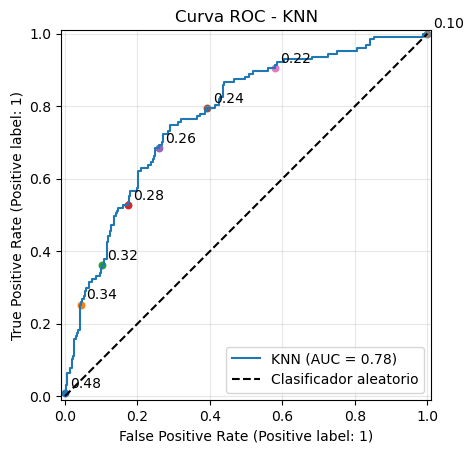

In [31]:
graficar_roc(
    busqueda_vecinos.best_estimator_,
    "KNN"
)

La curva ROC de KNN alcanza un AUCROC de 0.776, mostrando una capacidad de discriminación claramente superior a la del árbol de decisión. La curva se mantiene bastante por encima de la diagonal, lo que indica un mejor equilibrio entre verdaderos positivos y falsos positivos a lo largo de distintos umbrales.

- SVM:

In [32]:
from sklearn.svm import SVC

#SVM también usa distancias/productos internos, así que sufre las escalas igual -> scaler dentro del pipeline (sin leakage).
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=SEED)),   # kernel RBF por defecto. Leer explicacion de abajo de scoring
])

#Al pipeline de SVM se le podia pasar SVC(proability = True) para que los scores tengan las probabilidades calibradas.
#Puntualmente, a nosotros no nos suma dado que el metodo de scoring, roc_auc, utiliza desicion_function (en vez de un
# predict proba) que devuelve scores continuos que responden: de que lado de la frontera cae el punto? 
# ej: -3 -> muy del lado negativo vs 0.5 -> un poco del lado positivo
# como roc_auc se base en ordenamiento, (proba de que una instancia postiiva reciba mayor score que una negativa)
# esto basta.



# Puede ser muy interesante variar el kernel, antes que fijar solo rbf. capaz incluso agregar un kernel mas y aumentar iter
espacio_svm = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100,  1000, 10000, 100000], # regularización: toleración de errores de margenes (ej: dato positivo cruza a negativo). Mientras mayor, mas castiga errores
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000], # regularización: toleración de errores de margenes (ej: dato positivo cruza a negativo). Mientras mayor, mas castiga errores
        "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1],# alcance del kernel RBF: gamma chico = influencia amplia (suave), gamma grande = influencia local (riesgo de overfit)
    }
]

busqueda_svm = RandomizedSearchCV(
    estimator=pipe_svm,
    param_distributions=espacio_svm,
    n_iter=20,               # 5 + 5*5 = 30 combinaciones. Muestrea 20
    scoring="roc_auc",       # usa decision_function por detrás: no hace falta probability=True
    cv=kf,                   # mismos folds que árbol y KNN -> comparación justa
    random_state=SEED,
    n_jobs=-1,
)

busqueda_svm.fit(X_train, y_train)

print("Mejor configuración:", busqueda_svm.best_params_)
print("Mejor AUCROC (CV):", busqueda_svm.best_score_)

resultados_svm = pd.DataFrame(busqueda_svm.cv_results_)
resultados_svm = resultados_svm.sort_values("rank_test_score")
resultados_svm[["params", "mean_test_score", "std_test_score"]].head(10)

Mejor configuración: {'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'svm__C': 10000}
Mejor AUCROC (CV): 0.7728221153846154


,params,mean_test_score,std_test_score
9,"{'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'sv...",0.772822,0.054865
1,"{'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'sv...",0.772822,0.054865
17,"{'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'sv...",0.772822,0.054865
18,"{'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'sv...",0.769829,0.058309
3,"{'svm__kernel': 'rbf', 'svm__gamma': 'scale', ...",0.752811,0.040695
14,"{'svm__kernel': 'rbf', 'svm__gamma': 'scale', ...",0.752811,0.040695
10,"{'svm__kernel': 'rbf', 'svm__gamma': 'scale', ...",0.737819,0.053107
15,"{'svm__kernel': 'rbf', 'svm__gamma': 'scale', ...",0.737699,0.054311
13,"{'svm__kernel': 'rbf', 'svm__gamma': 0.001, 's...",0.701597,0.029557
4,"{'svm__kernel': 'rbf', 'svm__gamma': 0.001, 's...",0.689010,0.024581


Se observó que, inicialmente, cuando el límite de la grilla explorada era 100, este valor formaba parte de la mejor combinación. Por ende, se agrandó la grilla del hiperparámetro para ver si 100 era un máximo real. Volviendo a correr la búsqueda se notó que había empate de mejor AUCROC medio para los modelos con C= 10, 10000 y 100000. Para estudiarlo más a fondo, se obtuvieron los valores variando valores de C y manteniendo fijos los hiperparámetros "kernel" y "gamma". Se vio que para C=10 en adelante el AUCROC es idéntico hasta el sexto decimal (0.772822) porque una vez que el margen deja de ser violado, C sale de la solución del problema de optimización y el modelo es literalmente el mismo, el umbral está entre 1 y 10. Más importante, la variación total en los ocho órdenes de magnitud es de 0.003, contra un desvío entre folds de 0.055. Esto quiere decir que la performance es insensible a C en todo el rango. Se reporta C=10 por ser el menor de los equivalentes.

In [33]:
from sklearn.model_selection import cross_val_score

valores_C = [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]

curva_C = []

for c in valores_C:
    # mismo pipeline (scaler + SVC), variando solo C; gamma y kernel fijos
    pipe_svm.set_params(svm__C=c, svm__gamma=0.01, svm__kernel="rbf")

    scores = cross_val_score(
        pipe_svm, X_train, y_train,
        cv=kf,                 # los mismos 5 folds de siempre
        scoring="roc_auc",
        n_jobs=-1,
    )

    curva_C.append({
        "C": c,
        "AUCROC medio": scores.mean(),
        "Desvío": scores.std(),
    })

curva_C_df = pd.DataFrame(curva_C)
curva_C_df

,C,AUCROC medio,Desvío
0,0.01,0.769929,0.057682
1,0.10,0.769829,0.058309
2,1.00,0.769580,0.058936
3,10.00,0.772822,0.054865
4,100.00,0.772822,0.054865
5,1000.00,0.772822,0.054865
6,10000.00,0.772822,0.054865
7,100000.00,0.772822,0.054865


Representación gráfica del mejor valor de AUCROC:

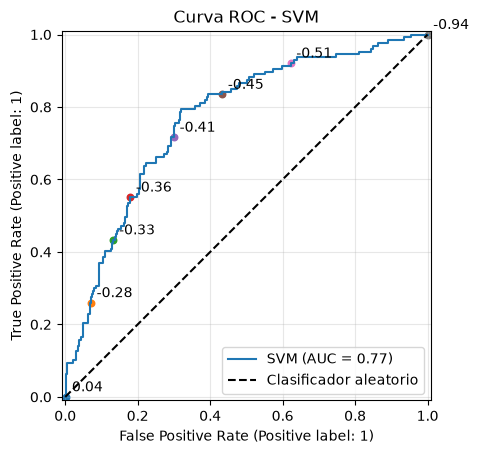

In [ ]:
graficar_roc(
    busqueda_svm.best_estimator_,
    "SVM"
)

La curva ROC de SVM alcanza un AUCROC de 0.768, lo que indica una buena capacidad de discriminación y un desempeño claramente superior al azar. Su performance es muy similar a la de KNN, aunque levemente inferior en términos de AUCROC.

### 3.2 Modelos Generativos

#### LDA (Linear Discriminant Analysis)

Parámetros por defecto:

1. solver: 'svd'. Algoritmo utilizado para resolver la optimización

2. shrinkage: None. Parámetro de regularización de la matriz de cov

3. priors: None. Probabilidades a priori de las clases

4. n_components: None. Número de componentes para reducción de dimensionalidad

5. store_covariance: False. Guarda la matriz de covarianza.

6. tol: 1e-4. Umbral de tol para considerar significativos los valores singulares del solver.

7. covariance_estimator: None. Permite pasar un estimador personalizado para la matriz de cov

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

#para guardar los resultados de los modelos baseline(LDA, Naive Bayes)
resultados_baseline = []
    
#Inicializamos el modelo con sus hiperparámetros por defecto.
lda = LinearDiscriminantAnalysis()

#Evaluamos mediante cross-validation con los mismos folds de los otros modelos para poder comparar resultados.
scores_lda = cross_val_score(lda, X_train, y_train, cv=kf, scoring="roc_auc", n_jobs=-1)


resultados_baseline.append({"Modelo": "LDA", "AUCROC Medio": scores_lda.mean(), "Desviación Estándar": scores_lda.std()})


#### Naive Bayes

Parámetros por defecto:

1. priors: None. Probabilidades a priori de las clases. Si es None se calculan a partir de los datos de entrenamiento.

2. var_smoothing: 10e-9. Funciona como un término de estabilidad/regularización en el denominador de la distribución Gaussiana.

In [ ]:
from sklearn.naive_bayes import GaussianNB

#Inicializamos el modelo con sus hiperparámetros por defecto.
gnb = GaussianNB()

#Evaluamos mediante cross-validation con los mismos folds de los otros modelos para poder comparar resultados.
scores_gnb = cross_val_score(gnb, X_train, y_train, cv=kf, scoring="roc_auc", n_jobs=-1)

resultados_baseline.append({"Modelo": "Naive Bayes", "AUCROC Medio": scores_gnb.mean(), "Desviación Estándar": scores_gnb.std()})

+ Resultados

In [ ]:
resultados_baseline_df = pd.DataFrame(resultados_baseline)

resultados_baseline_df

,Modelo,AUCROC Medio,Desviación Estándar
0,LDA,0.61276,0.045911
1,Naive Bayes,0.72579,0.058682
